In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("credit_risk_dataset.csv")

In [4]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Loan status 0: 25473 Percentage 0: 78.18%
Loan status 1: 7108 Percentage 1: 21.82%


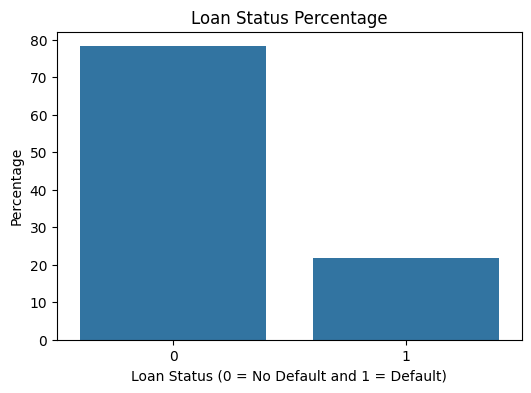

In [5]:
#Checking the default to non-default loan ratios of the dataset
status_count = df["loan_status"].value_counts()
status_percentage = df["loan_status"].value_counts(normalize = True) *100

for status, percentage in status_percentage.items():
    print(f"Loan status {status}: {status_count[status]} Percentage {status}: {percentage:.2f}%")

plt.figure(figsize=(6,4))
plt.title("Loan Status Percentage")
plt.xlabel("Loan Status (0 = No Default and 1 = Default)")
plt.ylabel("Percentage")
sns.barplot(x=status_percentage.index, y=status_percentage.values)

plt.show()




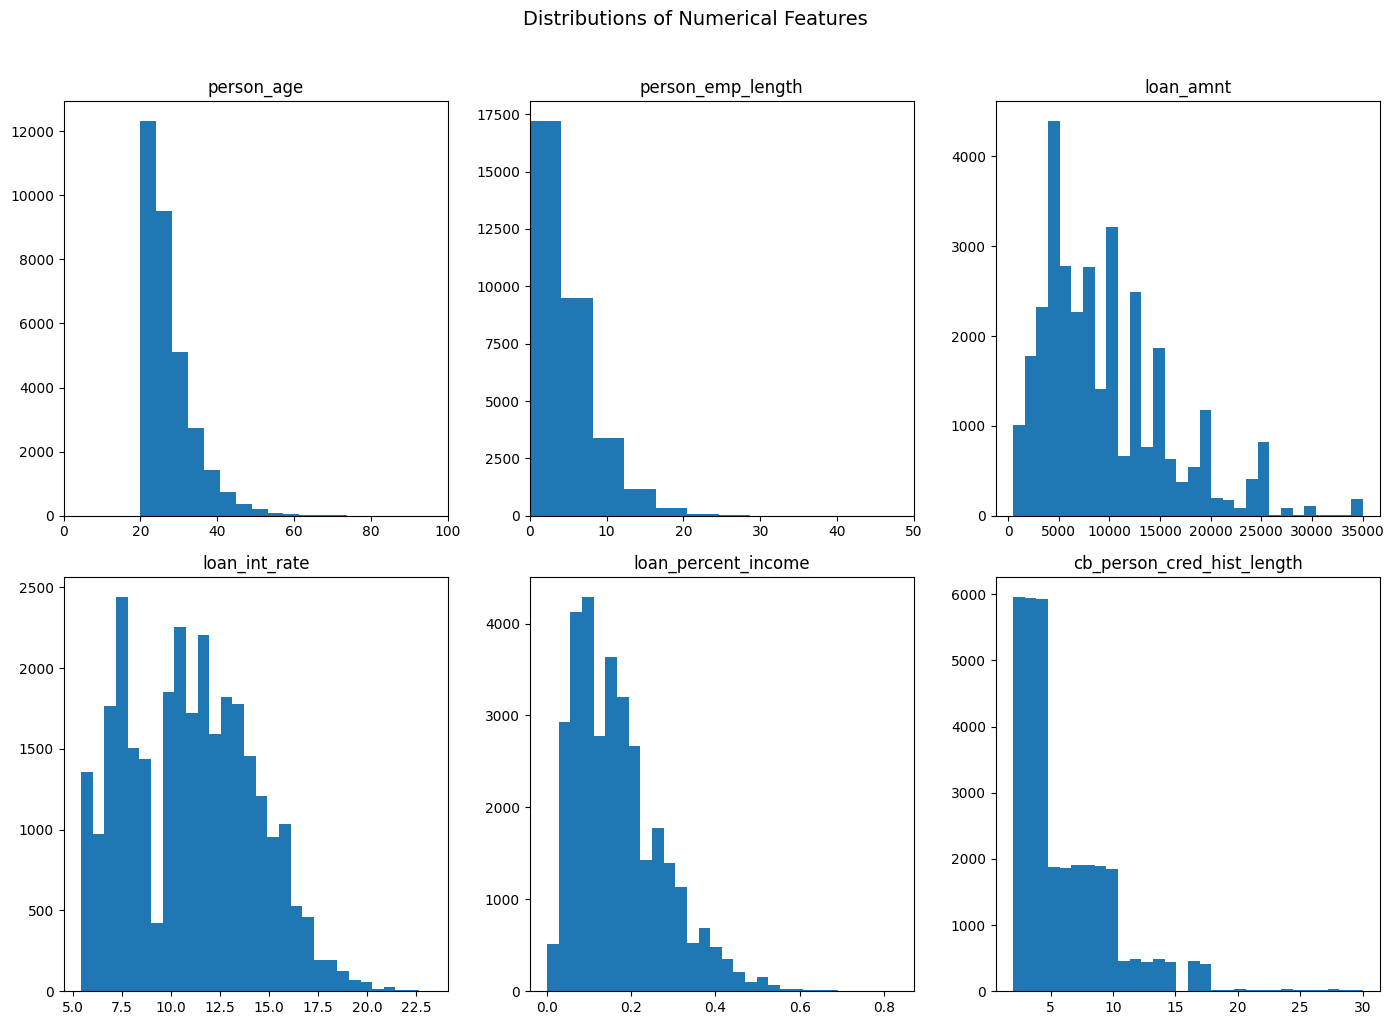

In [6]:
num_cols = ['person_age', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col)

    if col in ['person_age']:
        axes[i].set_xlim(0, 100)
    if col in ['person_emp_length']:
        axes[i].set_xlim(0,50)

plt.suptitle('Distributions of Numerical Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()



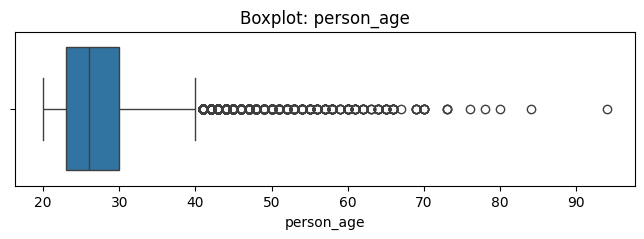

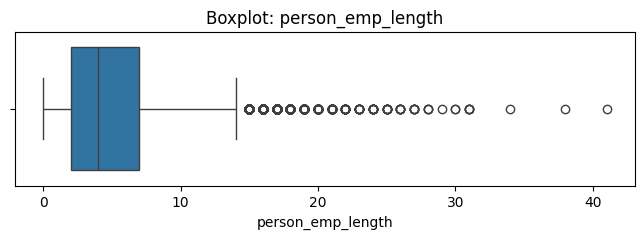

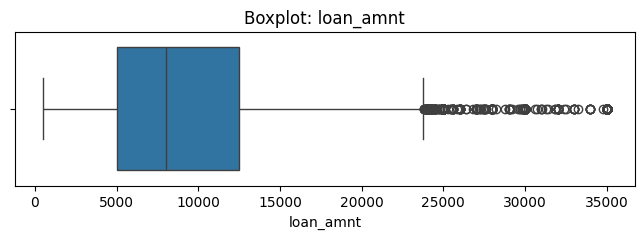

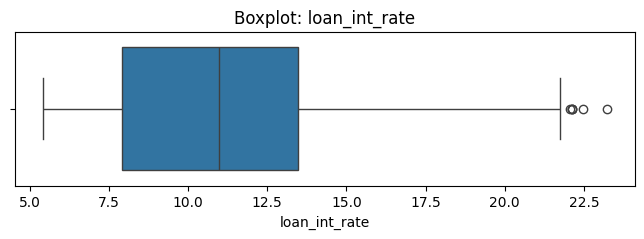

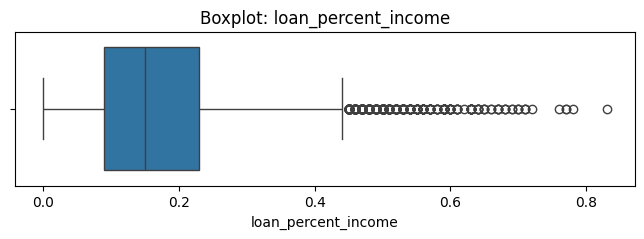

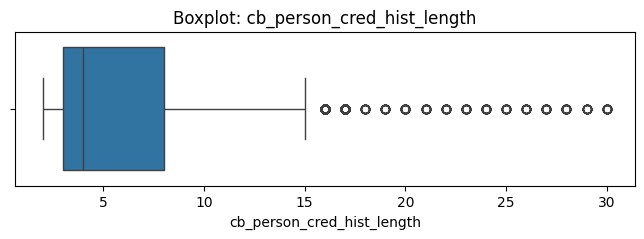

In [ ]:
#Check for outliers
for col in num_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')

df = df[df["person_age"] <= 100]
df = df[df["person_emp_length"] <= 70] 
plt.show()
